### Import Dependencies

In [1]:
%pip install Sastrawi

Note: you may need to restart the kernel to use updated packages.


In [2]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import pandas as pd
import matplotlib.pyplot as plt
import math


[nltk_data] Downloading package punkt to C:\Users\HP
[nltk_data]     840\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


### Define Sentence

In [3]:
sentence = """Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. Buka peluang investasi sektor strategis
Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.

"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.

Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.

"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola nvestasi secara profesional dan akuntabel," ungkapnya.

Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia. Jangan lupa ikuti update berita lainnya dan follow  akun
Google News Metrotvnews.com dan Channel WhatsApp Metro TV

(Eko Nordiansyah)"""

### Text Processing

In [5]:
# Sentence tokenization
sent_token = sent_tokenize(sentence)
print(sent_token)

['Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.', 'Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.', 'Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.', 'Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.', 'Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.', '"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 20

Tokenisasi digunakan untuk memecah sentence menjadi sebuah token yang dipisah berdasarkan tanda baca seperti ., ?, atau ! agar mudah diproses.

In [6]:
# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)


Cleaned sentences (Indonesian stop words removed):
Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi telah disepakati Qatar.
Kesepakatan Indonesia Qatar merupakan buah kunjungan resmi Presiden Prabowo Subianto Doha.
Pemerintah Republik Indonesia Pemerintah Qatar menggelar diskusi menyepakati kemitraan strategis (co-partnership) pengelolaan dana investasi Indonesia akan berfokus berbagai sektor pembangunan.
Salah satu hasil utama kunjungan tersebut untuk membentuk dana investasi bersama senilai USD4 miliar.
Dana akan difokuskan pengembangan berbagai sektor antaranya termasuk tidak terbatas hilirisasi industri, energi terbarukan, fasilitas kesehatan Indonesia.
"Kami menyambut baik kepercayaan diberikan Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani keterangan tertulis, Selasa, 15 April 2025.
Presiden Prabowo menyampaikan masing-masing negara berkontribusi sebesar USD2 m

In [7]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)

# Feature names
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)


TF-IDF Feature Matrix (Sparse) on cleaned sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 258 stored elements and shape (16, 182)>
  Coords	Values
  (0, 64)	0.2733240153603889
  (0, 10)	0.2733240153603889
  (0, 129)	0.23803069806504162
  (0, 62)	0.3053107330181949
  (0, 32)	0.2733240153603889
  (0, 6)	0.2733240153603889
  (0, 121)	0.2733240153603889
  (0, 21)	0.23803069806504162
  (0, 31)	0.19356637681607897
  (0, 158)	0.23803069806504162
  (0, 102)	0.2733240153603889
  (0, 144)	0.2733240153603889
  (0, 163)	0.2733240153603889
  (0, 40)	0.2733240153603889
  (0, 142)	0.16427847714067775
  (1, 142)	0.20416630136644331
  (1, 78)	0.33968876667251363
  (1, 57)	0.17697939391137998
  (1, 111)	0.2958260149562747
  (1, 22)	0.33968876667251363
  (1, 83)	0.2958260149562747
  (1, 147)	0.33968876667251363
  (1, 138)	0.2958260149562747
  (1, 137)	0.2958260149562747
  (1, 160)	0.33968876667251363
  :	:
  (14, 82)	0.21466591176448785
  (14, 123)	0.21466591176448785
  (14, 133

In [8]:
# TF-IDF untuk kalimat pertama
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF values for the first cleaned sentence:
[[0.         0.         0.         0.         0.         0.
  0.27332402 0.         0.         0.         0.27332402 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.2380307  0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.19356638 0.27332402 0.         0.         0.
  0.         0.         0.         0.         0.27332402 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.30531073 0.         0.27332402 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.     

In [9]:
# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

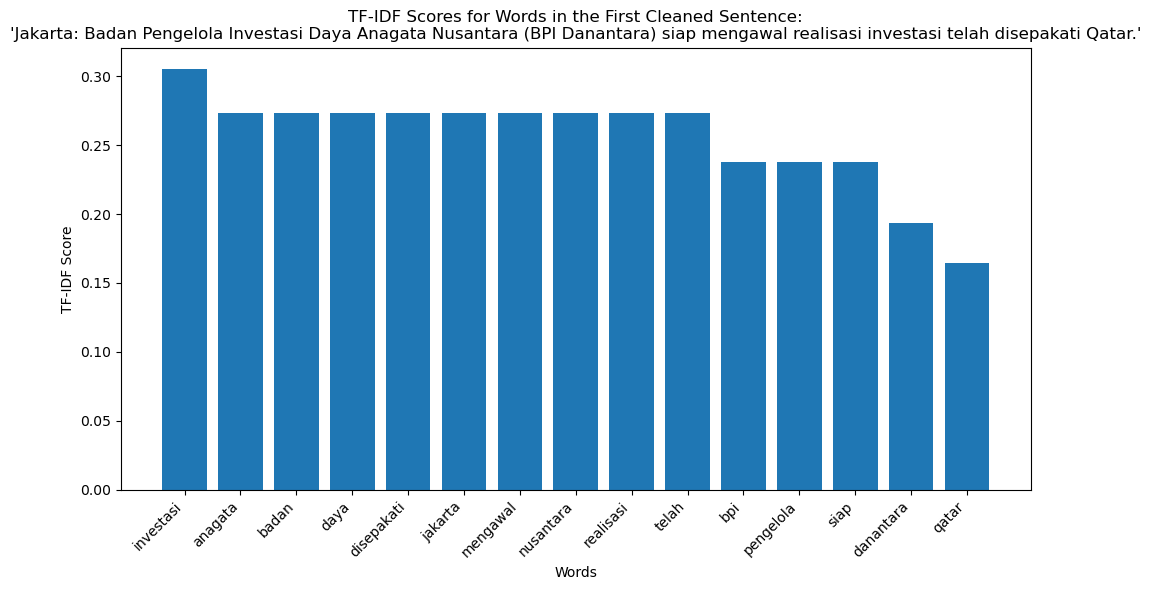

In [10]:
# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualisasi
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

TF-IDF yang telah dihitung akan divisualisasikan untuk melihat kata mana yang paling penting setelah dilakukan pembersihan (stopword removal).

In [12]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

**List of Sentences:**
1. Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
2. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
3. Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
4. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
5. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.
6. "Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertu

In [13]:
# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)


**Average TF-IDF Score for Each Sentence:**
- Sentence 1
  Sum of TF-IDF scores: 3.8371638194135773
  Number of words: 15
  Average TF-IDF score: 0.2558109212942385
- Sentence 2
  Sum of TF-IDF scores: 3.26289358846549
  Number of words: 11
  Average TF-IDF score: 0.2966266898604991
- Sentence 3
  Sum of TF-IDF scores: 4.187001878090137
  Number of words: 19
  Average TF-IDF score: 0.2203685198994809
- Sentence 4
  Sum of TF-IDF scores: 3.682269126752843
  Number of words: 14
  Average TF-IDF score: 0.2630192233394888
- Sentence 5
  Sum of TF-IDF scores: 4.066194385981777
  Number of words: 17
  Average TF-IDF score: 0.23918790505775156
- Sentence 6
  Sum of TF-IDF scores: 4.928302699223024
  Number of words: 25
  Average TF-IDF score: 0.19713210796892094
- Sentence 7
  Sum of TF-IDF scores: 3.123269943251901
  Number of words: 11
  Average TF-IDF score: 0.28393363120471826
- Sentence 8
  Sum of TF-IDF scores: 3.4082170861903323
  Number of words: 12
  Average TF-IDF score: 0.28401809

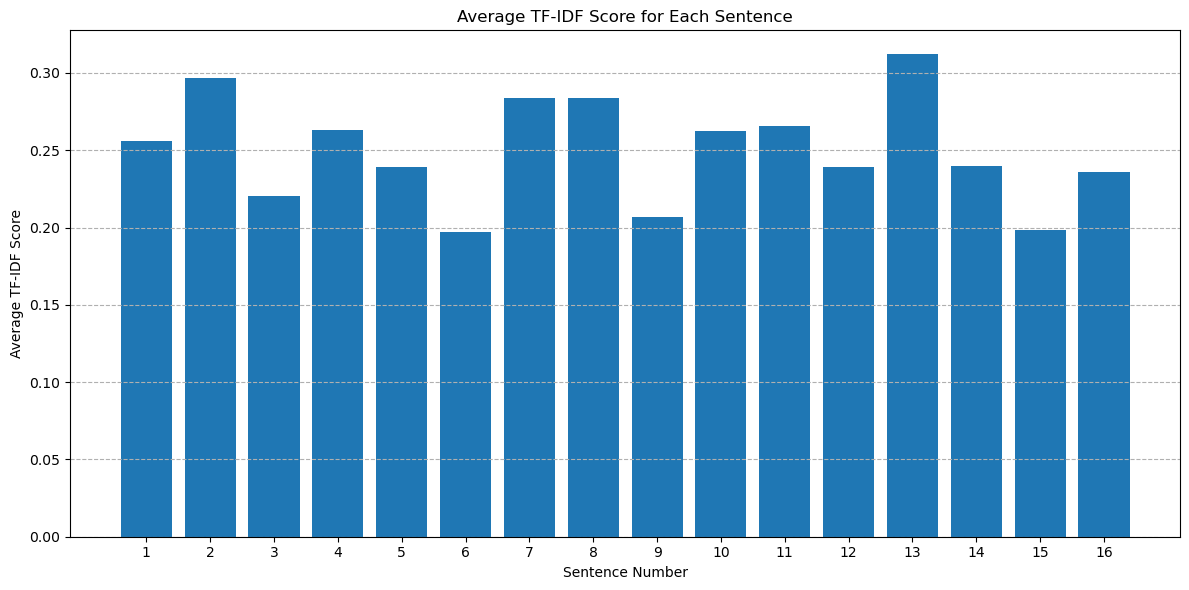

In [14]:
# Visualisasi
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### Hitung Threshold Kalimat

In [15]:
# Hitung skor tiap kalimat
sent_scores = []
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Hitung threshold (rata-rata semua skor kalimat)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.24996411348685135
